# **Access to Safe Drinking Water is Essential for Health**

#### Access to safe drinking water is a fundamental human right and a cornerstone of global public health. Ensuring water potability not only protects communities from waterborne diseases but also drives significant economic benefits. 
#### In this project, I will analyze a comprehensive dataset containing water quality metrics for 3,276 different water sources. By examining key chemical and physical parameters—such as pH, hardness, sulfate levels, and turbidity— I aim to perform a thorough exploratory data analysis, address missing values, and ultimately understand the defining characteristics that classify water as safe for human consumption.



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


#### The file water_potability.csv contains water quality criteria for 3,276 different water sources. 

## 1. **Data Inspection:**

In [2]:
data = pd.read_csv('src/water_potability.csv')
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


#### To see a concise summary of the dataframe's columns, data types, and non-null values:

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [4]:
df = pd.DataFrame(data)

In [5]:
df.describe(include = 'all')

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [6]:
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

#### For a better vision, we will use a custom function to clearly display the variables alongside their total counts, unique values, and the exact number of missing entries:

In [7]:
def describe(df):

    variables = []
    count = []
    unique = []
    missing_values = []

    for col in df.columns:
        variables.append(col)
        count.append(df[col].count())
        unique.append(len(df[col].unique()))
        missing_values.append(df[col].isna().sum())

    result = pd.DataFrame({
        'variables' : variables,
        'count' : count,
        'unique' : unique,
        'missing_values' : missing_values
    })

    return result


describe(df)

,variables,count,unique,missing_values
0,ph,2785,2786,491
1,Hardness,3276,3276,0
2,Solids,3276,3276,0
3,Chloramines,3276,3276,0
4,Sulfate,2495,2496,781
5,Conductivity,3276,3276,0
6,Organic_carbon,3276,3276,0
7,Trihalomethanes,3114,3115,162
8,Turbidity,3276,3276,0
9,Potability,3276,2,0


#### Since there are more than 1000 missing values, two approaches are possible:

## 2. **Handling the missing values:**

### 2.1. **Deleting the missing values:**

In [8]:
df_cleaned = df.dropna()
describe(df_cleaned)

,variables,count,unique,missing_values
0,ph,2011,2011,0
1,Hardness,2011,2011,0
2,Solids,2011,2011,0
3,Chloramines,2011,2011,0
4,Sulfate,2011,2011,0
5,Conductivity,2011,2011,0
6,Organic_carbon,2011,2011,0
7,Trihalomethanes,2011,2011,0
8,Turbidity,2011,2011,0
9,Potability,2011,2,0


#### The number of deleted missing values are not justifiable.

### **2.1 Imputing the missing values:** (Selected approach)

In [9]:
def simple_knn_impute(df, target_col, k=10, debug=True ,debug_samples=2):
    # df = main data | target_col = with missing value | k = number of neighbors | debug = it's just a flag for me :)
    df = df.copy() 
    feature_cols = [
        col for col in df.columns # all of columns
        if col != target_col and df[col].isna().sum() == 0 # target and other missing values should be ingnore
    ]

    shown = 0 # For shown some rows 

    known = df[df[target_col].notna()] 
    missing = df[df[target_col].isna()] 

    for idx, row in missing.iterrows(): # idx = index | row = the row
        
        diffs = known[feature_cols].sub(row[feature_cols]).abs()

        distances = diffs.sum(axis=1) # Manhattan distance (L1)

        nearest_idx = distances.nsmallest(k).index # k nearest neighbors (KNN)

        imputed_value = known.loc[nearest_idx, target_col].mean() # Mean of knn

        df.at[idx, target_col] = imputed_value # The null value = now has a value

        if debug and shown < debug_samples:
            print(f"Missing sample index: {idx}")
            print("Missing row:")
            display(df.loc[[idx]])

            print("Nearest neighbors:")
            display(df.loc[nearest_idx])

            print(f"Imputed value for '{target_col}': {imputed_value:.4f}")
            print("Nearest neighbors indices:")
            print(list(nearest_idx))

            print("\nNeighbor values:")
            print(known.loc[nearest_idx, target_col].values)

            shown += 1

    return df

In [10]:
df_imputed = simple_knn_impute(df, 'Sulfate', k=10, debug_samples=2)

Missing sample index: 1
Missing row:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
1,3.71608,129.422921,18630.057858,6.635246,341.794864,592.885359,15.180013,56.329076,4.500656,0


Nearest neighbors:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
2992,NaN,196.083556,18592.083920,7.245436,321.814033,552.879034,15.664786,81.080826,4.762872,0
685,3.994498,179.454192,18682.277139,6.464793,331.145621,538.174959,13.916820,NaN,3.379147,1
2314,5.161879,179.636409,18666.563638,5.196133,400.896023,485.311954,14.059708,75.822050,4.320101,1
1347,6.265637,159.290190,18711.064662,6.835968,314.223053,499.604629,15.061714,68.107216,3.266029,0
1513,6.353437,218.549363,18664.844297,6.690394,312.393019,503.414897,15.422459,94.386932,3.861109,1
1562,NaN,190.567521,18589.031160,7.470353,362.146977,471.444769,13.760231,90.306310,4.400203,1
331,NaN,163.224466,18570.285339,8.109346,296.190262,463.741716,16.900148,61.349832,4.135745,1
2154,NaN,209.953278,18668.363826,4.453252,347.581603,479.561362,16.092975,68.799179,3.772078,0
2514,6.528479,176.939676,18533.337828,6.083268,336.296413,491.477924,13.531264,96.944104,4.063276,0
1139,6.284386,222.688795,18526.261691,8.980271,395.261637,517.150548,15.869010,55.384333,5.030712,1


Imputed value for 'Sulfate': 341.7949
Nearest neighbors indices:
[2992, 685, 2314, 1347, 1513, 1562, 331, 2154, 2514, 1139]

Neighbor values:
[321.8140325  331.14562114 400.89602333 314.2230526  312.39301924
 362.14697732 296.19026162 347.58160322 336.29641311 395.26163712]
Missing sample index: 2
Missing row:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
2,8.099124,224.236259,19909.541732,9.275884,337.839297,418.606213,16.868637,66.420093,3.055934,0


Nearest neighbors:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
989,5.392058,198.017165,19900.407838,7.843226,348.951924,419.813956,14.616509,80.568252,2.978925,0
3013,NaN,215.431919,19909.938849,6.902628,299.086418,371.482911,10.766349,85.267182,4.592538,0
755,9.888941,220.638823,19892.388914,7.986456,326.076560,460.812425,14.929172,59.602808,3.750164,1
3214,5.500277,263.683160,19911.224900,4.755312,366.942743,435.865696,12.761184,51.439894,5.147536,1
2104,NaN,165.740229,19919.324589,7.278151,351.965054,420.120713,17.776053,46.002340,3.428096,0
653,5.970579,202.745520,19952.309470,7.872038,311.188185,412.038922,18.632142,73.166338,5.013281,0
3109,6.283679,205.376624,19905.436548,7.078345,284.206021,471.904032,18.027160,64.362608,4.480771,0
1960,8.128270,231.167537,19954.575554,5.138838,349.067363,386.071149,15.018085,63.340968,4.678742,1
2289,9.130607,226.403741,19968.677835,5.723792,386.699776,440.543099,11.751718,NaN,5.288487,0
635,6.715719,195.190599,19966.744697,7.744696,354.208923,411.795503,17.323081,67.981741,2.443008,0


Imputed value for 'Sulfate': 337.8393
Nearest neighbors indices:
[989, 3013, 755, 3214, 2104, 653, 3109, 1960, 2289, 635]

Neighbor values:
[348.95192435 299.0864179  326.07656028 366.94274325 351.96505382
 311.18818474 284.20602148 349.06736269 386.69977643 354.20892319]


In [11]:
describe(df_imputed)

,variables,count,unique,missing_values
0,ph,2785,2786,491
1,Hardness,3276,3276,0
2,Solids,3276,3276,0
3,Chloramines,3276,3276,0
4,Sulfate,3276,3267,0
5,Conductivity,3276,3276,0
6,Organic_carbon,3276,3276,0
7,Trihalomethanes,3114,3115,162
8,Turbidity,3276,3276,0
9,Potability,3276,2,0


#### We repeated this process for the other features with missing values:

In [12]:
df_imputed = simple_knn_impute(df_imputed, 'ph', k=10, debug_samples=2)
df_imputed = simple_knn_impute(df_imputed, 'Trihalomethanes', k=10, debug_samples=2)


Missing sample index: 0
Missing row:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.399471,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.99097,2.963135,0


Nearest neighbors:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
2471,7.575758,203.884373,20855.272321,8.109312,334.027420,532.311188,14.236013,74.638706,3.176433,0
2449,4.439096,190.153449,20864.340465,2.386653,332.054407,515.631205,18.081003,63.363082,3.844231,1
1410,6.381977,211.917276,20709.279762,6.171162,278.949273,525.075478,16.684074,74.529806,4.991896,0
2172,7.950817,147.117918,20827.917578,9.226125,321.982743,474.854039,10.714241,60.255519,4.543685,0
406,4.725786,249.670999,20834.294278,5.036010,378.998684,411.114485,17.769641,78.817436,3.156331,1
1849,8.613699,235.944436,20862.455871,7.622565,378.758715,418.697530,13.608075,NaN,3.949220,0
447,9.112786,205.941072,20868.627979,6.962790,330.934290,422.039495,16.128976,77.796530,4.567088,0
2784,6.758656,190.337280,20666.453159,6.783660,319.263363,484.608711,9.784777,86.695451,2.743890,1
242,9.436637,143.788412,20724.930359,7.700100,318.451494,469.761328,14.215765,66.077978,4.411117,0
1345,8.999499,234.835477,20933.512750,7.980451,365.060966,444.077017,12.168764,54.404704,3.695084,0


Imputed value for 'ph': 7.3995
Nearest neighbors indices:
[2471, 2449, 1410, 2172, 406, 1849, 447, 2784, 242, 1345]

Neighbor values:
[7.57575788 4.43909578 6.38197711 7.95081658 4.72578556 8.61369859
 9.11278625 6.75865647 9.43663716 8.99949894]
Missing sample index: 8
Missing row:


...

Imputed value for 'Trihalomethanes': 64.6735
Nearest neighbors indices:
[1560, 2969, 1804, 936, 1624, 1403, 134, 273, 2018, 804]

Neighbor values:
[77.55495328 60.19235078 72.23652477 70.52597177 66.4205789  96.44212932
 41.86595951 71.14666068 33.43986771 56.91025406]
Missing sample index: 81
Missing row:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
81,5.519126,168.728583,12531.601921,7.730723,362.937522,443.570372,18.099078,70.647569,3.758996,0


Nearest neighbors:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
237,6.937819,177.578142,12626.197922,7.380883,345.780175,439.624998,9.348252,83.163242,3.724090,0
2874,8.339437,175.596742,12629.853049,6.976314,345.780175,452.337520,17.528839,101.851393,4.133696,0
1658,6.090016,216.736232,12558.897973,9.297300,317.983236,409.427236,10.754842,30.965844,2.943522,0
1590,7.740384,179.302381,12477.771818,9.989628,421.393990,471.783153,8.412402,66.163439,3.013361,1
836,8.054886,200.943484,12642.065947,7.309822,334.442064,446.748442,14.949080,71.202038,3.514098,0
1236,7.104295,177.571744,12691.515973,7.170977,351.829816,447.032289,14.376764,60.743770,5.464857,0
2025,7.338826,229.978694,12603.400371,5.975488,351.318826,370.860632,19.389337,79.971647,4.017061,1
2182,5.915807,195.744074,12431.803110,6.661616,380.725336,367.854025,21.300647,90.394895,4.513201,0
2110,8.524296,141.810243,12658.177161,11.264386,347.268092,387.085887,12.789958,69.577099,4.343060,0
539,7.784736,204.923829,12556.754047,5.789008,359.951766,610.767576,16.012643,52.442326,3.257744,0


Imputed value for 'Trihalomethanes': 70.6476
Nearest neighbors indices:
[237, 2874, 1658, 1590, 836, 1236, 2025, 2182, 2110, 539]

Neighbor values:
[ 83.1632417  101.85139313  30.96584429  66.16343924  71.20203815
  60.74376989  79.97164725  90.39489472  69.57709863  52.44232579]


#### Now we have a DataFrame without missing values:

In [13]:
describe(df_imputed)

,variables,count,unique,missing_values
0,ph,3276,3272,0
1,Hardness,3276,3276,0
2,Solids,3276,3276,0
3,Chloramines,3276,3276,0
4,Sulfate,3276,3267,0
5,Conductivity,3276,3276,0
6,Organic_carbon,3276,3276,0
7,Trihalomethanes,3276,3276,0
8,Turbidity,3276,3276,0
9,Potability,3276,2,0


## 3. **Data Visualization**

### 3.1. **pH vs. Hardness**

#### **pH Value:**  
#### pH is an important parameter for evaluating the acid-base balance in water. It indicates whether water is acidic or alkaline. The World Health Organization (WHO) has declared the allowable range (marked with dashed line) for pH to be between 6.5 and 8.5. In the current investigation, the pH range was between 6.52 and 6.83, which falls within the standard WHO range.

#### **Hardness:** 
#### Water hardness is primarily caused by the presence of calcium and magnesium salts. These salts dissolve from earth layers along the path of water flow; the longer the contact time, the higher the hardness of the raw water. Historically, hardness was defined by the water's ability to precipitate soap due to these minerals.

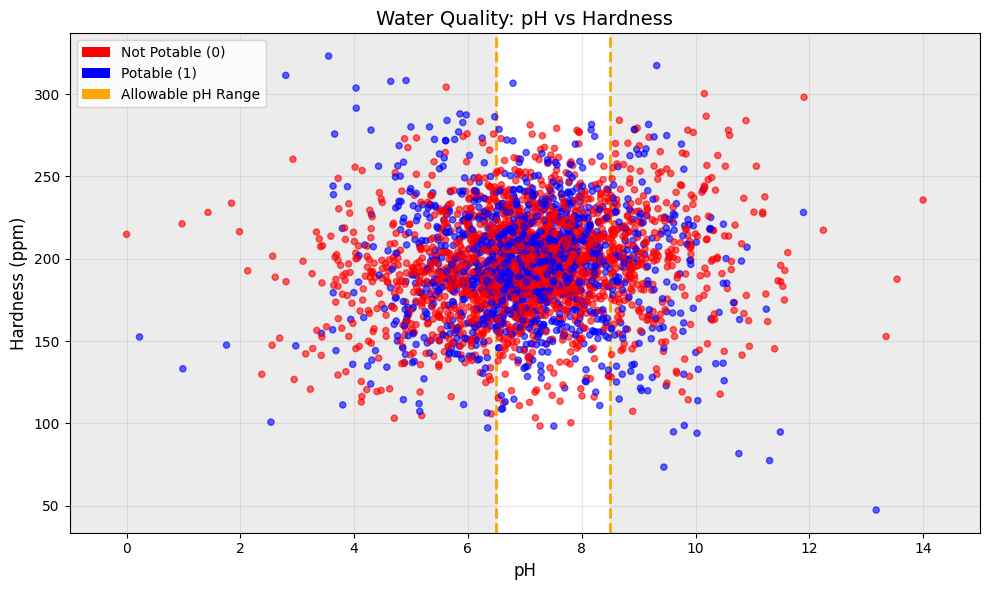

In [14]:
# Extract data columns for plotting
x = df_imputed['ph']
y = df_imputed['Hardness']
potability = df_imputed['Potability']

# Map potability values to colors (red for not potable, blue for potable)
colors = []

for p in potability:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Define pH boundaries for water potability zones
ph_max_potability = 8.5
ph_min_potability = 6.5  

# Shade regions outside the acceptable pH range (non-potable zones)
ax.axvspan(ph_max_potability, 15, alpha=0.15, color='gray', zorder=0)  # Right of line 2
ax.axvspan(-1, ph_min_potability, alpha=0.15, color='gray', zorder=0)  # Left of line 2

# Draw vertical boundary lines for pH thresholds
ax.axvline(x=ph_max_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_max_potability}')
ax.axvline(x=ph_min_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_min_potability}')

# Plot the data points
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

# Configure axis limits and labels
ax.set_xlim(-1, 15)
ax.set_xlabel('pH', fontsize=12)
ax.set_ylabel('Hardness (ppm)', fontsize=12)
ax.set_title('Water Quality: pH vs Hardness', fontsize=14)
ax.grid(True, alpha=0.3)

# Add legend to distinguish potable vs non-potable water samples
legend_elements = [Patch(facecolor='red', label='Not Potable (0)'),
                   Patch(facecolor='blue', label='Potable (1)'),
                   Patch(facecolor='orange', label='Allowable pH Range')]
ax.legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.show()


### 3.2. **pH vs. TDS**

#### **Total Dissolved Solids (TDS):** 
#### Water can dissolve various organic and inorganic minerals such as potassium, calcium, sodium, bicarbonates, chlorides, magnesium, and sulfates. These substances can impart an undesirable taste or dilute color to the water. TDS is a key indicator of water quality; water with high TDS is considered highly mineralized. The desirable TDS limit is 500 mg/L, with a maximum allowable limit for drinking set at 1000 mg/L.

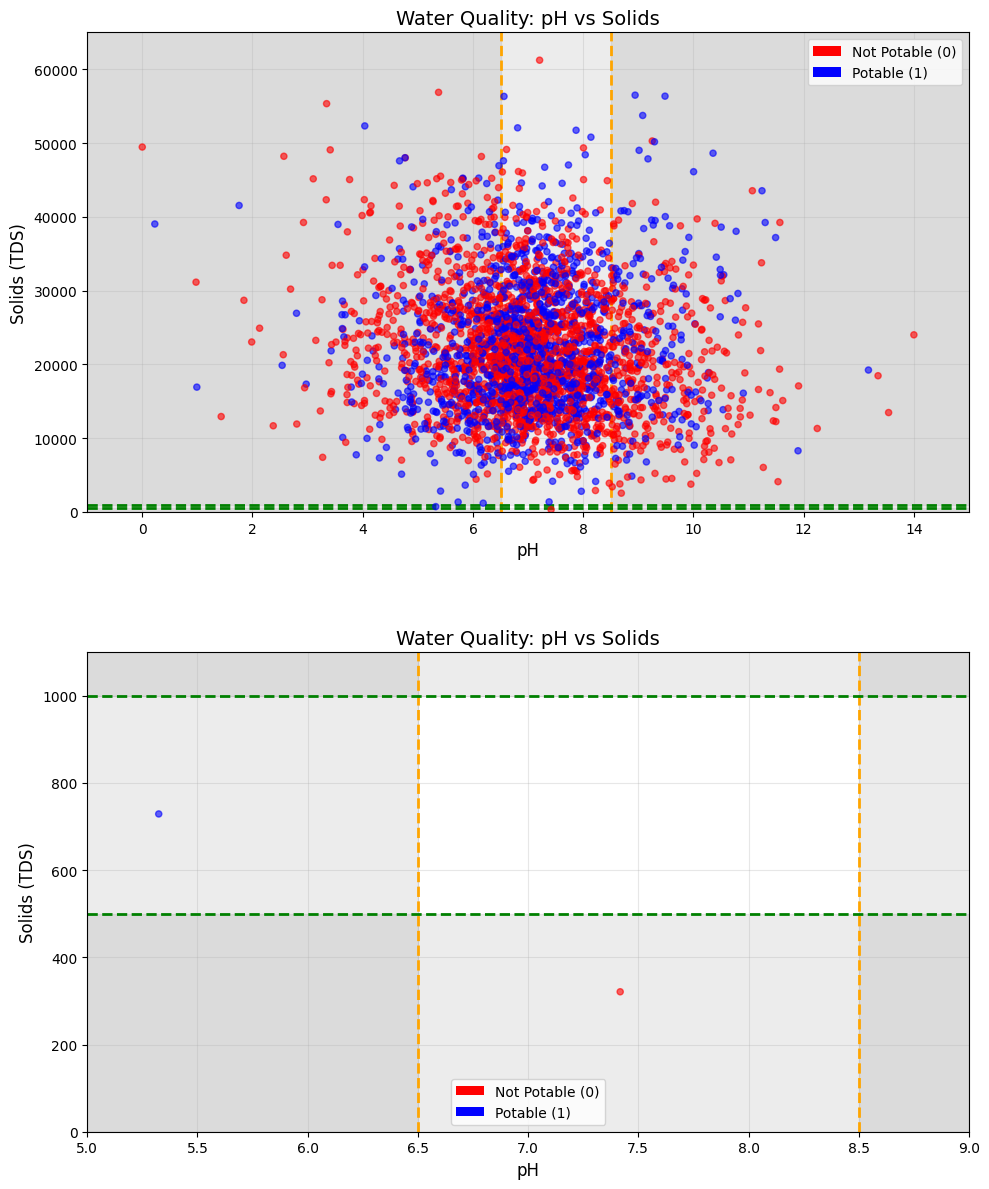

In [15]:
# Visualize pH vs Total Dissolved Solids (TDS) with water potability indicators
# Two subplots: full range view and zoomed view of acceptable ranges

# Extract feature columns for visualization
x = df_imputed['ph']
y = df_imputed['Solids']
potability = df_imputed['Potability']

# Color mapping: red = non-potable water (0), blue = potable water (1)
colors = []

for p in potability:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

# Initialize figure with two vertically stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12) , dpi=100)

# Define acceptable water quality thresholds
ph_max_potability = 8.5
ph_min_potability = 6.5  

TDS_max_potability = 1000
TDS_min_potability = 500 

# === SUBPLOT 1: Full range view ===

# Highlight non-potable pH zones (outside 6.5-8.5 range)
ax1.axvspan(ph_max_potability, 15, alpha=0.15, color='gray', zorder=0)  # High pH zone
ax1.axvspan(-1, ph_min_potability, alpha=0.15, color='gray', zorder=0)  # Low pH zone

# Highlight non-potable TDS zones (outside 500-1000 ppm range)
ax1.axhspan(0, TDS_min_potability, alpha=0.15, color='gray', zorder=0)  # Low TDS zone
ax1.axhspan(TDS_max_potability, 70000, alpha=0.15, color='gray', zorder=0)  # High TDS zone

# Draw pH threshold boundary lines
ax1.axvline(x=ph_max_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_max_potability}')
ax1.axvline(x=ph_min_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_min_potability}')

# Draw TDS threshold boundary lines
ax1.axhline(y=TDS_max_potability, color='green', linestyle='--', linewidth=2, label=f'TDS = {TDS_max_potability}')
ax1.axhline(y=TDS_min_potability, color='green', linestyle='--', linewidth=2, label=f'TDS = {TDS_min_potability}')

# Scatter plot of all water samples
ax1.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

# Configure plot appearance for full view
ax1.set_xlim(-1, 15)
ax1.set_ylim(0, 65000)
ax1.set_xlabel('pH', fontsize=12)
ax1.set_ylabel('Solids (TDS)', fontsize=12)
ax1.set_title('Water Quality: pH vs Solids', fontsize=14)
ax1.grid(True, alpha=0.3)

# Add color legend for potability classification
legend_elements = [Patch(facecolor='red', label='Not Potable (0)'),
                   Patch(facecolor='blue', label='Potable (1)')]
ax1.legend(handles=legend_elements, loc='best')

# === SUBPLOT 2: Zoomed view of acceptable ranges ===

# Highlight non-potable pH zones
ax2.axvspan(ph_max_potability, 15, alpha=0.15, color='gray', zorder=0)
ax2.axvspan(-1, ph_min_potability, alpha=0.15, color='gray', zorder=0)

# Highlight non-potable TDS zones
ax2.axhspan(0, TDS_min_potability, alpha=0.15, color='gray', zorder=0)
ax2.axhspan(TDS_max_potability, 70000, alpha=0.15, color='gray', zorder=0)

# Draw pH threshold boundary lines
ax2.axvline(x=ph_max_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_max_potability}')
ax2.axvline(x=ph_min_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_min_potability}')

# Draw TDS threshold boundary lines
ax2.axhline(y=TDS_max_potability, color='green', linestyle='--', linewidth=2, label=f'TDS = {TDS_max_potability}')
ax2.axhline(y=TDS_min_potability, color='green', linestyle='--', linewidth=2, label=f'TDS = {TDS_min_potability}')

# Scatter plot of all water samples
ax2.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

# Configure plot appearance for zoomed view
ax2.set_xlim(5, 9)
ax2.set_ylim(0, 1100)
ax2.set_xlabel('pH', fontsize=12)
ax2.set_ylabel('Solids (TDS)', fontsize=12)
ax2.set_title('Water Quality: pH vs Solids', fontsize=14)
ax2.grid(True, alpha=0.3)

# Add color legend for potability classification
legend_elements = [Patch(facecolor='red', label='Not Potable (0)'),
                   Patch(facecolor='blue', label='Potable (1)')]
ax2.legend(handles=legend_elements, loc='best')

# Adjust spacing between subplots and display
plt.tight_layout(h_pad=5.0)
plt.show()


### 3.3. **pH vs. Chloramines:**

#### **Chloramines:**
#### Chlorine and chloramines are the primary disinfectants used in municipal water systems. Chloramine typically forms when ammonia is added to chlorine to disinfect drinking water. Chlorine levels up to 4 mg/L (or 4 ppm) in drinking water are considered safe.

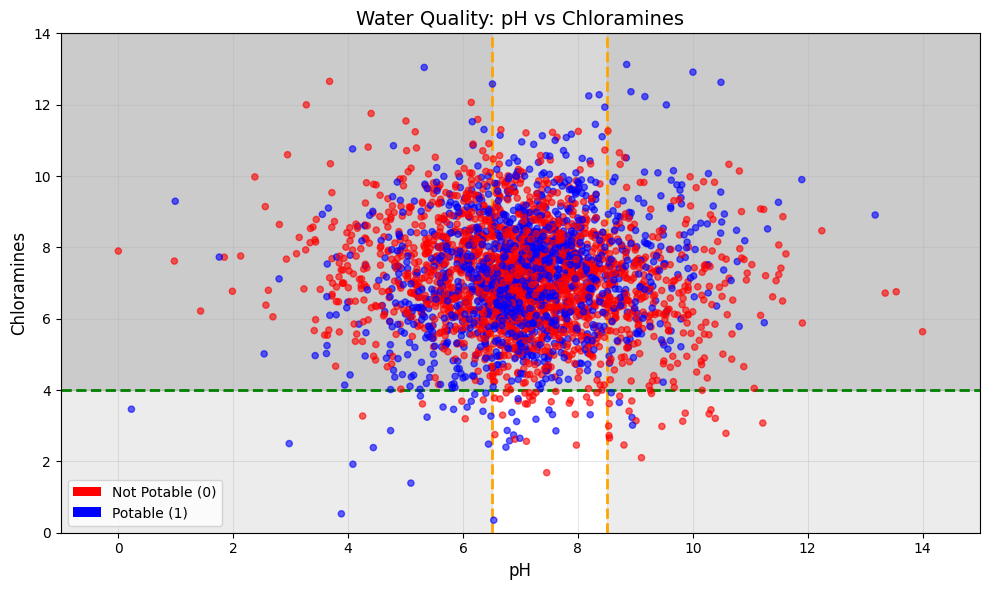

In [16]:
# Visualize pH vs Chloramines with water potability indicators

# Extract feature columns for visualization
x = df_imputed['ph']
y = df_imputed['Chloramines']
potability = df_imputed['Potability']

# Color mapping: red = non-potable water (0), blue = potable water (1)
colors = []

for p in potability:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

# Initialize figure and axis
fig, (ax) = plt.subplots(figsize=(10, 6))

# Define acceptable water quality thresholds
ph_max_potability = 8.5
ph_min_potability = 6.5  

chloramines_max_potability = 4

# Highlight non-potable pH zones (outside 6.5-8.5 range)
ax.axvspan(ph_max_potability, 15, alpha=0.15, color='gray', zorder=0)  # High pH zone
ax.axvspan(-1, ph_min_potability, alpha=0.15, color='gray', zorder=0)  # Low pH zone

# Highlight non-potable chloramines zone (above 4 ppm)
ax.axhspan(chloramines_max_potability, 14, alpha=0.3, color='gray', zorder=0)  # High chloramines zone

# Draw pH threshold boundary lines
ax.axvline(x=ph_max_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_max_potability}')
ax.axvline(x=ph_min_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_min_potability}')

# Draw chloramines threshold boundary line
ax.axhline(y=chloramines_max_potability, color='green', linestyle='--', linewidth=2, label=f'Chloramines = {chloramines_max_potability}')

# Scatter plot of all water samples
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

# Configure plot appearance
ax.set_xlim(-1, 15)
ax.set_ylim(0, 14)
ax.set_xlabel('pH', fontsize=12)
ax.set_ylabel('Chloramines', fontsize=12)
ax.set_title('Water Quality: pH vs Chloramines', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for potability classification
legend_elements = [Patch(facecolor='red', label='Not Potable (0)'),
                   Patch(facecolor='blue', label='Potable (1)')]
ax.legend(handles=legend_elements, loc='best')

# Display the plot
plt.tight_layout()
plt.show()


### 3.4. **pH vs. Sulfate:**

#### **Sulfate:**
#### Sulfates occur naturally in soil and rock minerals and are found in the air, groundwater, plants, and food. Their primary commercial use is in the chemical industry. Sulfate concentration in seawater is about 2700 mg/L, while most freshwater sources range between 3 to 30 mg/L, though some areas report up to 1000 mg/L.


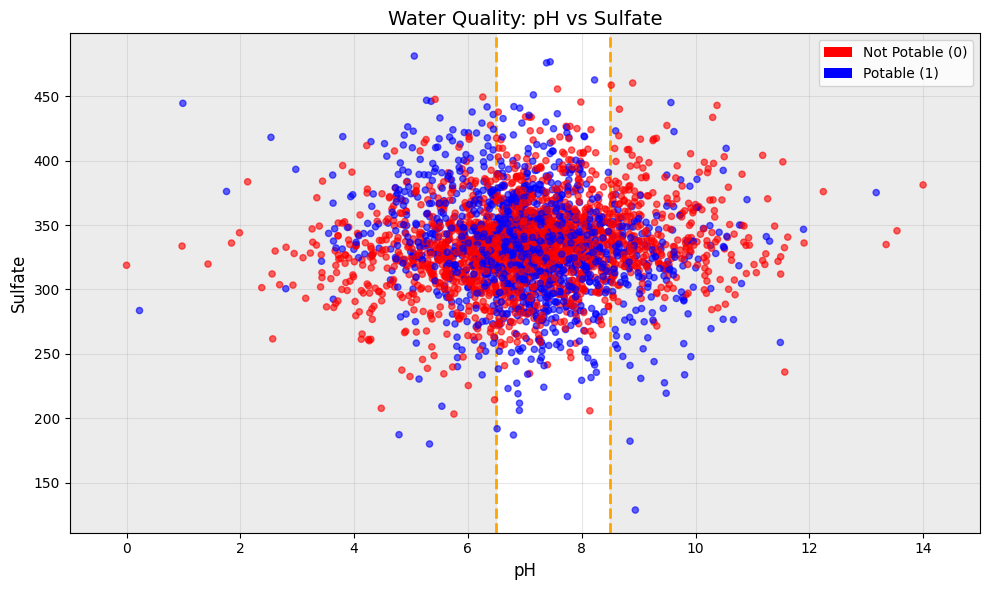

In [17]:
# Visualize pH vs Sulfate with water potability indicators

# Extract feature columns for visualization
x = df_imputed['ph']
y = df_imputed['Sulfate']
potability = df_imputed['Potability']

# Color mapping: red = non-potable water (0), blue = potable water (1)
colors = []

for p in potability:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

# Initialize figure and axis
fig, (ax) = plt.subplots(figsize=(10, 6))

# Define acceptable water quality thresholds
ph_max_potability = 8.5
ph_min_potability = 6.5  

# Highlight non-potable pH zones (outside 6.5-8.5 range)
ax.axvspan(ph_max_potability, 15, alpha=0.15, color='gray', zorder=0)  # High pH zone
ax.axvspan(-1, ph_min_potability, alpha=0.15, color='gray', zorder=0)  # Low pH zone

# Draw pH threshold boundary lines
ax.axvline(x=ph_max_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_max_potability}')
ax.axvline(x=ph_min_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_min_potability}')

# Scatter plot of all water samples
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

# Configure plot appearance
ax.set_xlim(-1, 15)
ax.set_xlabel('pH', fontsize=12)
ax.set_ylabel('Sulfate', fontsize=12)
ax.set_title('Water Quality: pH vs Sulfate', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for potability classification
legend_elements = [Patch(facecolor='red', label='Not Potable (0)'),
                   Patch(facecolor='blue', label='Potable (1)')]
ax.legend(handles=legend_elements, loc='best')

# Display the plot
plt.tight_layout()
plt.show()


### 3.5. **pH vs. EC:**

#### **Electrical Conductivity (EC):** 
#### Pure water is a poor conductor of electricity and acts as an insulator. An increase in ion concentration increases the electrical conductivity. Generally, the amount of dissolved solids determines the conductivity level. EC measures the solution's ability to transmit an electric current. According to WHO standards, EC should not exceed 400 μS/cm.

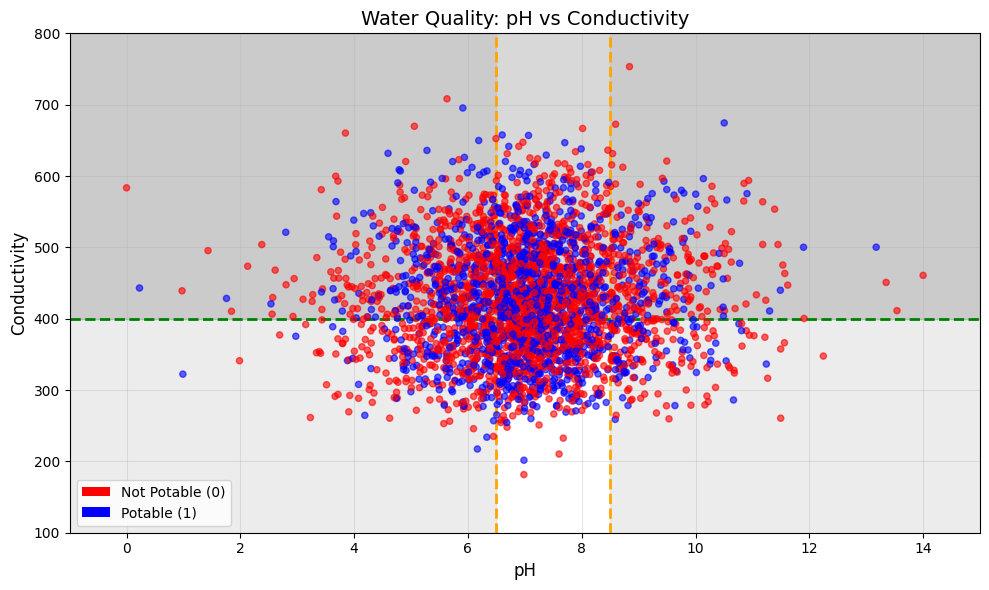

In [18]:
# Visualize pH vs Conductivity with water potability indicators

# Extract feature columns for visualization
x = df_imputed['ph']
y = df_imputed['Conductivity']
potability = df_imputed['Potability']

# Color mapping: red = non-potable water (0), blue = potable water (1)
colors = []

for p in potability:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

# Initialize figure and axis
fig, (ax) = plt.subplots(figsize=(10, 6))

# Define acceptable water quality thresholds
ph_max_potability = 8.5
ph_min_potability = 6.5  

conductivity_max_potability = 400

# Highlight non-potable pH zones (outside 6.5-8.5 range)
ax.axvspan(ph_max_potability, 15, alpha=0.15, color='gray', zorder=0)  # High pH zone
ax.axvspan(-1, ph_min_potability, alpha=0.15, color='gray', zorder=0)  # Low pH zone

# Highlight non-potable conductivity zone (above 400 µS/cm)
ax.axhspan(conductivity_max_potability, 800, alpha=0.3, color='gray', zorder=0)  # High conductivity zone

# Draw pH threshold boundary lines
ax.axvline(x=ph_max_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_max_potability}')
ax.axvline(x=ph_min_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_min_potability}')

# Draw conductivity threshold boundary line
ax.axhline(y=conductivity_max_potability, color='green', linestyle='--', linewidth=2, label=f'Conductivity = {conductivity_max_potability}')

# Scatter plot of all water samples
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

# Configure plot appearance
ax.set_xlim(-1, 15)
ax.set_ylim(100, 800)
ax.set_xlabel('pH', fontsize=12)
ax.set_ylabel('Conductivity', fontsize=12)
ax.set_title('Water Quality: pH vs Conductivity', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for potability classification
legend_elements = [Patch(facecolor='red', label='Not Potable (0)'),
                   Patch(facecolor='blue', label='Potable (1)')]
ax.legend(handles=legend_elements, loc='best')

# Display the plot
plt.tight_layout()
plt.show()


### 3.6. **pH vs. TOC:**

#### **Total Organic Carbon (TOC):**
#### TOC in water sources results from the decay of natural organic matter as well as synthetic sources. It measures the total amount of carbon in organic compounds in pure water. According to US EPA standards, TOC should be less than 2 mg/L in treated drinking water and less than 4 mg/L in source water.

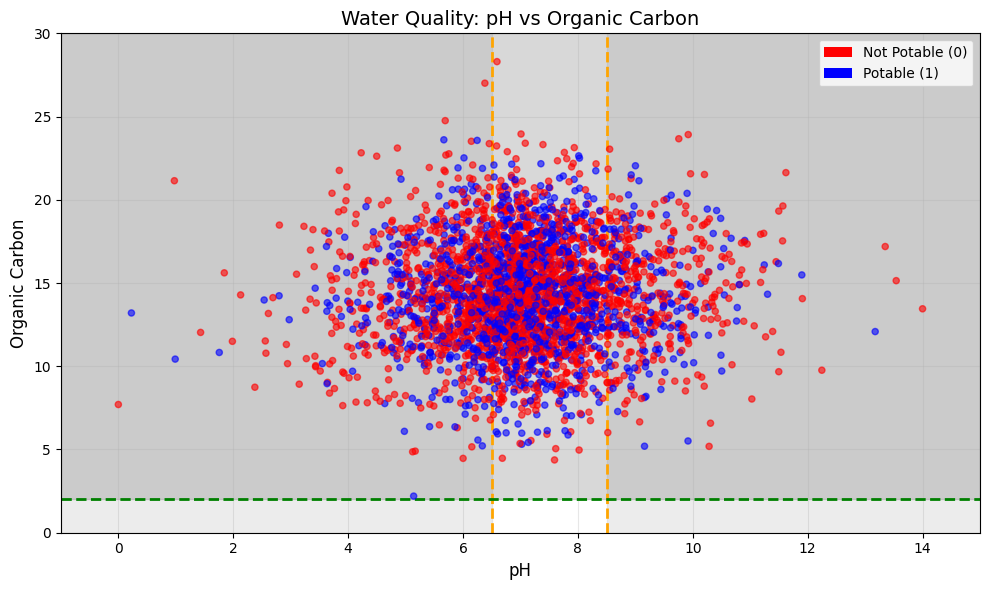

In [19]:
# Visualize pH vs Organic Carbon with water potability indicators

# Extract feature columns for visualization
x = df_imputed['ph']
y = df_imputed['Organic_carbon']
potability = df_imputed['Potability']

# Color mapping: red = non-potable water (0), blue = potable water (1)
colors = []

for p in potability:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

# Initialize figure and axis
fig, (ax) = plt.subplots(figsize=(10, 6))

# Define acceptable water quality thresholds
ph_max_potability = 8.5
ph_min_potability = 6.5  

organic_carbon_max_potability = 2

# Highlight non-potable pH zones (outside 6.5-8.5 range)
ax.axvspan(ph_max_potability, 15, alpha=0.15, color='gray', zorder=0)  # High pH zone
ax.axvspan(-1, ph_min_potability, alpha=0.15, color='gray', zorder=0)  # Low pH zone

# Highlight non-potable organic carbon zone (above 2 mg/L)
ax.axhspan(organic_carbon_max_potability, 30, alpha=0.3, color='gray', zorder=0)  # High organic carbon zone

# Draw pH threshold boundary lines
ax.axvline(x=ph_max_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_max_potability}')
ax.axvline(x=ph_min_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_min_potability}')

# Draw organic carbon threshold boundary line
ax.axhline(y=organic_carbon_max_potability, color='green', linestyle='--', linewidth=2, label=f'Organic Carbon = {organic_carbon_max_potability}')

# Scatter plot of all water samples
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

# Configure plot appearance
ax.set_xlim(-1, 15)
ax.set_ylim(0, 30)
ax.set_xlabel('pH', fontsize=12)
ax.set_ylabel('Organic Carbon', fontsize=12)
ax.set_title('Water Quality: pH vs Organic Carbon', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for potability classification
legend_elements = [Patch(facecolor='red', label='Not Potable (0)'),
                   Patch(facecolor='blue', label='Potable (1)')]
ax.legend(handles=legend_elements, loc='best')

# Display the plot
plt.tight_layout()
plt.show()


### 3.7. **pH vs. THM:**

#### **Trihalomethanes (THM):**
#### These are chemical compounds that may be found in water treated with chlorine. Their concentration depends on the amount of organic matter, the amount of chlorine used, and the water temperature during treatment. THM levels up to 80 ppm are considered safe in drinking water.

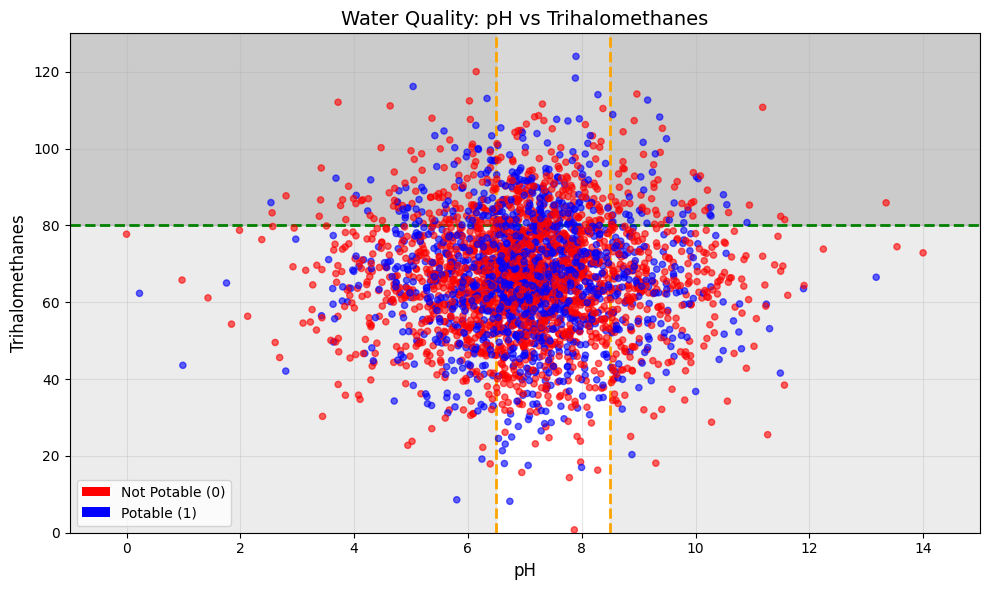

In [20]:
# Visualize pH vs Trihalomethanes with water potability indicators

# Extract feature columns for visualization
x = df_imputed['ph']
y = df_imputed['Trihalomethanes']
potability = df_imputed['Potability']

# Color mapping: red = non-potable water (0), blue = potable water (1)
colors = []

for p in potability:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

# Initialize figure and axis
fig, (ax) = plt.subplots(figsize=(10, 6))

# Define acceptable water quality thresholds
ph_max_potability = 8.5
ph_min_potability = 6.5  

trihalomethanes_max_potability = 80

# Highlight non-potable pH zones (outside 6.5-8.5 range)
ax.axvspan(ph_max_potability, 15, alpha=0.15, color='gray', zorder=0)  # High pH zone
ax.axvspan(-1, ph_min_potability, alpha=0.15, color='gray', zorder=0)  # Low pH zone

# Highlight non-potable trihalomethanes zone (above 80 µg/L)
ax.axhspan(trihalomethanes_max_potability, 130, alpha=0.3, color='gray', zorder=0)  # High trihalomethanes zone

# Draw pH threshold boundary lines
ax.axvline(x=ph_max_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_max_potability}')
ax.axvline(x=ph_min_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_min_potability}')

# Draw trihalomethanes threshold boundary line
ax.axhline(y=trihalomethanes_max_potability, color='green', linestyle='--', linewidth=2, label=f'Trihalomethanes = {trihalomethanes_max_potability}')

# Scatter plot of all water samples
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

# Configure plot appearance
ax.set_xlim(-1, 15)
ax.set_ylim(0, 130)
ax.set_xlabel('pH', fontsize=12)
ax.set_ylabel('Trihalomethanes', fontsize=12)
ax.set_title('Water Quality: pH vs Trihalomethanes', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for potability classification
legend_elements = [Patch(facecolor='red', label='Not Potable (0)'),
                   Patch(facecolor='blue', label='Potable (1)')]
ax.legend(handles=legend_elements, loc='best')

# Display the plot
plt.tight_layout()
plt.show()


### 3.8. **pH vs. Turbidity:**

#### **Turbidity:**
#### This depends on the amount of suspended solid particles in the water. It measures light passage through the water and is used to evaluate effluent quality regarding colloidal substances. The average turbidity obtained at Wondo Genet University was 0.0098 NTU, which is less than the WHO recommended value of 5.000 NTU.

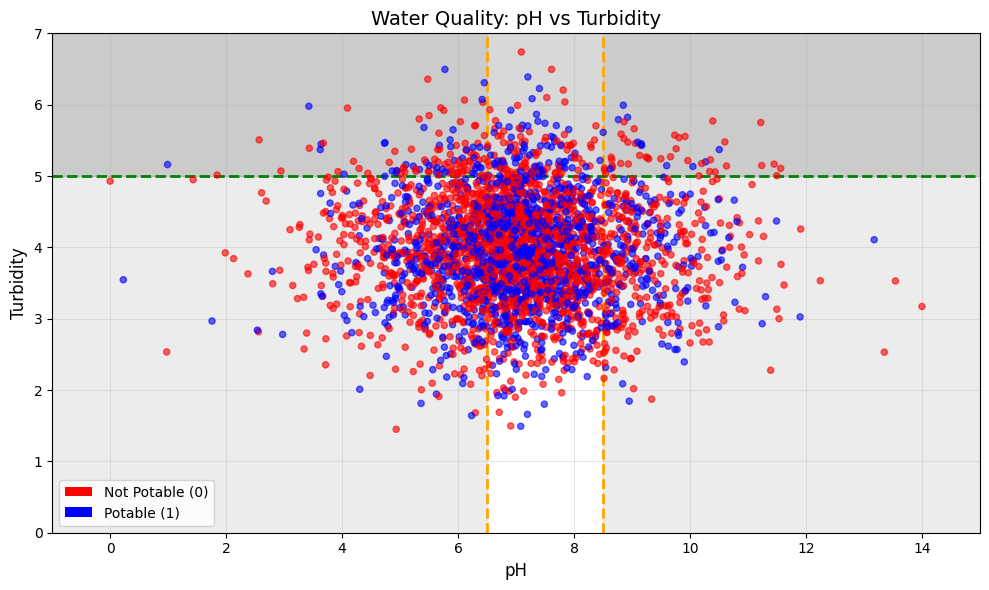

In [21]:
# Visualize pH vs Turbidity with water potability indicators

# Extract feature columns for visualization
x = df_imputed['ph']
y = df_imputed['Turbidity']
potability = df_imputed['Potability']

# Color mapping: red = non-potable water (0), blue = potable water (1)
colors = []

for p in potability:
    if p == 0:
        colors.append('red')
    else:
        colors.append('blue')

# Initialize figure and axis
fig, (ax) = plt.subplots(figsize=(10, 6))

# Define acceptable water quality thresholds
ph_max_potability = 8.5
ph_min_potability = 6.5  

turbidity_max_potability = 5

# Highlight non-potable pH zones (outside 6.5-8.5 range)
ax.axvspan(ph_max_potability, 15, alpha=0.15, color='gray', zorder=0)  # High pH zone
ax.axvspan(-1, ph_min_potability, alpha=0.15, color='gray', zorder=0)  # Low pH zone

# Highlight non-potable turbidity zone (above 5 NTU)
ax.axhspan(turbidity_max_potability, 7, alpha=0.3, color='gray', zorder=0)  # High turbidity zone

# Draw pH threshold boundary lines
ax.axvline(x=ph_max_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_max_potability}')
ax.axvline(x=ph_min_potability, color='orange', linestyle='--', linewidth=2, label=f'pH = {ph_min_potability}')

# Draw turbidity threshold boundary line
ax.axhline(y=turbidity_max_potability, color='green', linestyle='--', linewidth=2, label=f'Turbidity = {turbidity_max_potability}')

# Scatter plot of all water samples
ax.scatter(x, y, marker='o', s=20, alpha=0.6, c=colors, zorder=2) 

# Configure plot appearance
ax.set_xlim(-1, 15)
ax.set_ylim(0, 7)
ax.set_xlabel('pH', fontsize=12)
ax.set_ylabel('Turbidity', fontsize=12)
ax.set_title('Water Quality: pH vs Turbidity', fontsize=14)
ax.grid(True, alpha=0.3)

# Add color legend for potability classification
legend_elements = [Patch(facecolor='red', label='Not Potable (0)'),
                   Patch(facecolor='blue', label='Potable (1)')]
ax.legend(handles=legend_elements, loc='best')

# Display the plot
plt.tight_layout()
plt.show()


## 4. Conclusion
#### The evidence and distributions observed during this analysis suggest that this dataset was likely synthetically generated rather than collected from real-world, natural water sources.